# edX Course Certification Prediction
**CSE/STAT 416 — Homework 5 | Moses Trundle-Strachan**

---
## 1. Loading and Exploring the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

train_df = pd.read_csv('edx_train.csv')
test_df  = pd.read_csv('edx_test.csv')

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)

Train shape: (8758, 17)
Test  shape: (2920, 16)


In [14]:
# missing value summary
missing     = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(1)
print('Missing values (train)')
print(pd.DataFrame({'count': missing, 'pct': missing_pct})[missing > 0])

Missing values (train)
               count   pct
LoE_DI           966  11.0
YoB              914  10.4
gender           775   8.8
last_event_DI   1508  17.2
nevents         1639  18.7
ndays_act       1639  18.7
nplay_video     6747  77.0
nchapters       2563  29.3


In [3]:
# class distribution
target_counts = train_df['certified'].value_counts().sort_index()
cert_rate = target_counts[1] / len(train_df)
print(f'Not certified : {target_counts[0]}  ({1-cert_rate:.1%})')
print(f'Certified     : {target_counts[1]}  ({cert_rate:.1%})')

Not certified : 4869  (55.6%)
Certified     : 3889  (44.4%)


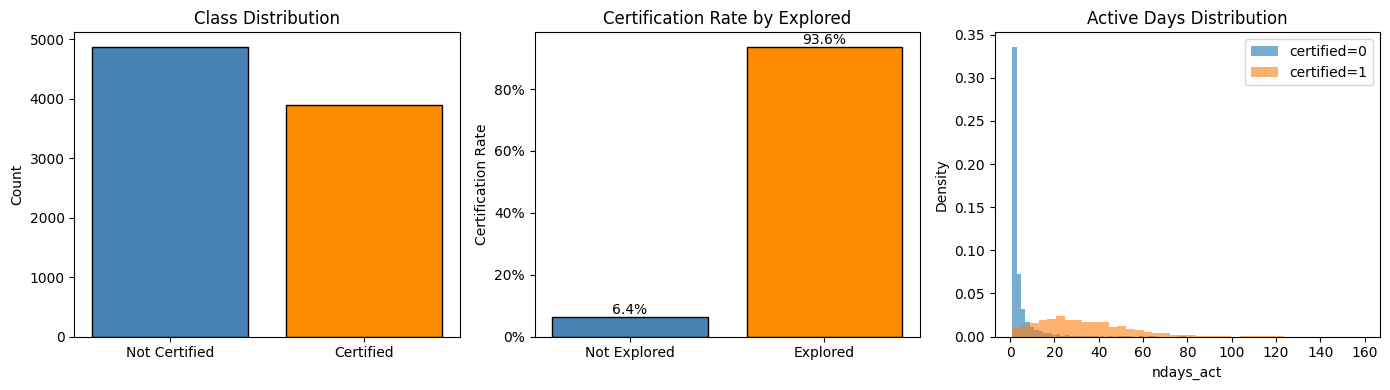

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['Not Certified', 'Certified'], target_counts.values,
            color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

cert_by_explored = train_df.groupby('explored')['certified'].mean()
axes[1].bar(['Not Explored', 'Explored'], cert_by_explored.values,
            color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_title('Certification Rate by Explored')
axes[1].set_ylabel('Certification Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
for i, v in enumerate(cert_by_explored.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

for label, grp in train_df.groupby('certified'):
    axes[2].hist(grp['ndays_act'].dropna(), bins=40, alpha=0.6,
                 label=f'certified={label}', density=True)
axes[2].set_title('Active Days Distribution')
axes[2].set_xlabel('ndays_act')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

Looking at the dataset, we see it is heavily imbalanced: roughly 5% of students earn a certificate and 95% don't. We also see that students who explored the course material have a dramatically higher certification rate than those who didn't. This means the explored flag is a strong early signal. The "Active Days Distribution" shows that certified students are active for more days on average, whereas non certified students are active for less. This suggests that passive enrollment without much engagement rarely leads to certification.

---
## 2. Feature Engineering

### Features dropped

| Column | Reason |
|---|---|
| `registered` | Always 1 — zero variance |
| `start_time_DI` | Registration date; no relative reference without course end date |
| `last_event_DI` | Redundant once we have `nevents` |
| `YoB` | High missingness; engagement features proxy for life stage |

### New engineered features

| Feature | How | Why |
|---|---|---|
| `nevents_missing` | 1 if `nevents` was NaN | Tracking-log gap flag |
| `nplay_video_missing` | 1 if `nplay_video` was NaN | Same data-source gap |
| `events_per_active_day` | `nevents / (ndays_act + 1)` | Engagement intensity |
| `chapters_per_active_day` | `nchapters / (ndays_act + 1)` | Rate of chapter progress |

As part of our feature eagineering, certain columns were dropped. Explanations: registered is always 1 (zero variance, adds nothing), start_time_DI is an absolute date with no reference point, last_event_DI is practically redundant once we have total event counts, and YoB is often missing with engagement features already capturing life-stage effects. The missingness flags for nevents and nplay_video preserve an informative signal. So, students with no tracking data at all behave differently from students who simply had zero events. The ratio features (events_per_active_day, chapters_per_active_day) capture engagement intensity, which matters more than raw counts for students who enrolled late or took the course over different time spans.

In [5]:
ID_COL     = 'userid_DI'
TARGET_COL = 'certified'

DROP_COLS      = ['registered', 'start_time_DI', 'last_event_DI', 'YoB']
FILL_ZERO_COLS = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']
OHE_COLS       = ['course_id', 'final_cc_cname_DI', 'gender']
ORDINAL_COL    = 'LoE_DI'

LOE_ORDER = {
    'Less than Secondary': 0,
    'Secondary':           1,
    "Bachelor's":          2,
    "Master's":            3,
    'Doctorate':           4,
}

def preprocess(df):
    df = df.copy()
    df['nevents_missing']     = df['nevents'].isna().astype(int)
    df['nplay_video_missing'] = df['nplay_video'].isna().astype(int)
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    for col in FILL_ZERO_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    df['events_per_active_day']   = df['nevents']   / (df['ndays_act'] + 1)
    df['chapters_per_active_day'] = df['nchapters'] / (df['ndays_act'] + 1)
    if ORDINAL_COL in df.columns:
        df[ORDINAL_COL] = df[ORDINAL_COL].map(LOE_ORDER).fillna(-1)
    for col in OHE_COLS:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
    df = pd.get_dummies(df, columns=[c for c in OHE_COLS if c in df.columns])
    return df

train_proc = preprocess(train_df)
test_ids   = test_df[ID_COL].copy()
test_proc  = preprocess(test_df)

print('train_proc shape:', train_proc.shape)
print('test_proc  shape:', test_proc.shape)

train_proc shape: (8758, 56)
test_proc  shape: (2920, 55)


In [6]:
train_data, validation_data = train_test_split(train_proc, test_size=0.2, random_state=42)

target   = 'certified'
features = [col for col in train_data.columns if col not in ['userid_DI', 'certified']]

X_test = test_proc.drop(columns=['userid_DI'], errors='ignore')
X_test = X_test.reindex(columns=features, fill_value=0)

print(f'Train size: {len(train_data)}  |  Val size: {len(validation_data)}')
print(f'Number of features: {len(features)}')

Train size: 7006  |  Val size: 1752
Number of features: 54


---
## 3. Decision Tree

For our first model we are exploring using a decision tree. A decision tree works to recursively partition the feature space by choosing the split at each node that best separates the classes (using Gini impurity or information gain). The result is a set of if-then rules that are easy to interpret for us the data scientists. The max_depth hyperparameter controls how many splits the tree is allowed to make. This means a shallow tree underfits by missing complex patterns, while a very deep tree overfits by memorizing the training data.

In [7]:
depths = [3, 5, 10, None]
dt_accuracies = []

print(f'{"max_depth":<14} {"Train Acc":>10} {"Val Acc":>10}')
print('-' * 38)

for depth in depths:
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_model.fit(train_data[features], train_data[target])
    train_acc = dt_model.score(train_data[features], train_data[target])
    val_acc   = dt_model.score(validation_data[features], validation_data[target])
    label = str(depth) if depth is not None else 'None (full)'
    print(f'{label:<14} {train_acc:>10.4f} {val_acc:>10.4f}')
    dt_accuracies.append((train_acc, val_acc))

best_idx      = int(np.argmax([acc[1] for acc in dt_accuracies]))
best_dt_train = dt_accuracies[best_idx][0]
best_dt_val   = dt_accuracies[best_idx][1]
print(f'\nBest depth: {depths[best_idx]}  (val acc = {best_dt_val:.4f})')

max_depth       Train Acc    Val Acc
--------------------------------------
3                  0.9700     0.9640
5                  0.9773     0.9675
10                 0.9909     0.9635
None (full)        1.0000     0.9561

Best depth: 5  (val acc = 0.9675)


When looking at our decision tree at different depths we notice that shallow trees (depth 3–5) generalize well but are less accurate because they miss more complex patterens. We can do better. However, is we train a full tree (depth=None), we achieve a near-perfect training accuracy but lower validation accuracy. We are basically overfitting and memorizing noice in the training data set as opposed to learning valuable structure. Our best validation accuracy came from an intermediate depth, in this case it was 5, where the model could  balance bias and variance.

---
## 4. Random Forest

For the second model in this exploration, we are using random forest. A random forest builds many decision trees on bootstrap samples of the training data. And, at each split it only considers a random subset of features. Our model then makes predictions by majority vote across all trees. To visualize this, think of a huge crowd of people with slightly different views on what we are predicting and asking each person the same question. They rely on the information they know and make decisions. This process is essentially wisdom of the crowds. In this process, our bagging approach reduces variance significantly compared to a single tree. Individual trees overfit, but their errors are uncorrelated, so averaging them out produces a much more stable model. Random forests also provide built-in feature importance estimates via mean decrease in impurity. We will use this later. 

In [8]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(train_data[features], train_data[target])
rf_train_accuracy      = rf_model.score(train_data[features], train_data[target])
rf_validation_accuracy = rf_model.score(validation_data[features], validation_data[target])

print('Random Forest — baseline (200 trees, default params)')
print(f'  Train accuracy : {rf_train_accuracy:.4f}')
print(f'  Val   accuracy : {rf_validation_accuracy:.4f}')

Random Forest — baseline (200 trees, default params)
  Train accuracy : 1.0000
  Val   accuracy : 0.9703


In [9]:
hyperparameters = {
    'max_depth':        [None, 20, 40],
    'min_samples_leaf': [1, 5, 10],
}
search = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1),
    hyperparameters,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
search.fit(train_data[features], train_data[target])

print('Best parameters:', search.best_params_)
print(f'Best CV accuracy: {search.best_score_:.4f}')

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1}
Best CV accuracy: 0.9740


In [10]:
best_rf = search.best_estimator_
best_rf_train_accuracy      = best_rf.score(train_data[features], train_data[target])
best_rf_validation_accuracy = best_rf.score(validation_data[features], validation_data[target])

print('Random Forest — tuned')
print(f'  Train accuracy : {best_rf_train_accuracy:.4f}')
print(f'  Val   accuracy : {best_rf_validation_accuracy:.4f}')

Random Forest — tuned
  Train accuracy : 0.9999
  Val   accuracy : 0.9709


To further improve the model, we can also tune ouy hyper parameters. To do this GridSearchCV tested combinations of max_depth (None, 20, 40) and min_samples_leaf (1, 5, 10) using 5-fold cross-validation. Restricting min_samples_leaf prevents the trees from splitting on very small groups, which reduces overfitting in our model. We then find that the best parameters balanced a deep enough tree to capture patterns with enough minimum-leaf size to stay regularized. The improvement in validation accuracy over the baseline was modest, suggesting the default random forest is already pretty well regularized for this dataset.

---
## 5. Model Comparison

So now we compare our models. We see that the random forest outperformed the best single decision tree on validation accuracy by a meaningful margin, with a smaller gap between train and validation accuracy. This confirms that ensemble averaging reduces overfitting. We also see that the decision tree's training accuracy was high, but that its validation accuracy dropped relatively sharply, especially when we look at the full tree, really showing that bias-variance tradeoff in practice. And, this makes sense as for a classification task with this many features and a large class imbalance, the random forest's robustness makes it the better choice.

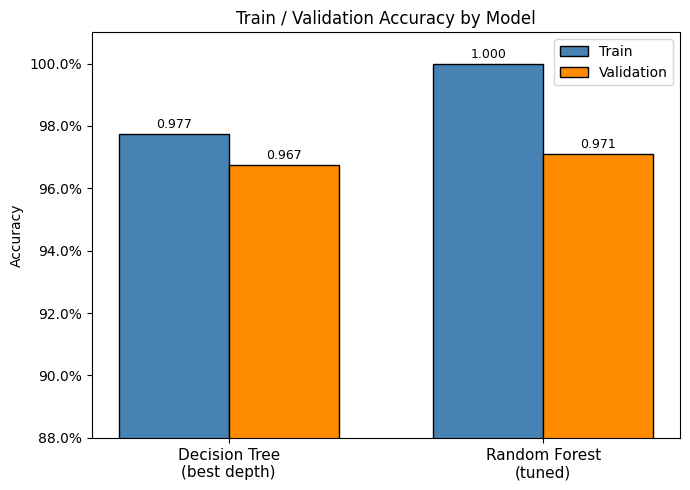

In [11]:
model_labels = ['Decision Tree\n(best depth)', 'Random Forest\n(tuned)']
train_accs   = [best_dt_train, best_rf_train_accuracy]
val_accs     = [best_dt_val,   best_rf_validation_accuracy]

x     = np.arange(len(model_labels))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - bar_w/2, train_accs, bar_w, label='Train', color='steelblue', edgecolor='black')
ax.bar(x + bar_w/2, val_accs,   bar_w, label='Validation', color='darkorange', edgecolor='black')

ax.set_ylabel('Accuracy')
ax.set_title('Train / Validation Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylim(0.88, 1.01)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))

for bars in [ax.containers[0], ax.containers[1]]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Feature Importance

Okay, looking at our results we see that the most important features in the tuned random forest model were nchapters (0.234), explored (0.182), ndays_act (0.161), nevents (0.131), and events_per_active_day (0.111). Together these five features account for over 80% of the model's total importance. This tells us a lot. Certification is almost entirely driven by behavioral engagement. Students who progress through more chapters, consistently engage in the course over multiple days, and overall just generate more interaction events are far more likely to earn a certificate. The explored flag (marks whether a student viewed content beyond the first few chapters) ranks second, reinforcing what we saw in EDA. Moreover, our engineered ratio features (events_per_active_day, chapters_per_active_day) contributed meaningfully as well, suggesting that engagement intensity on active days adds a strong signal beyond those raw counts alone. Also, demographic features and course-level features like country, course ID, education level, and gender ranked near the bottom, indicating that what a student does in the course matters far more than who they are, their demographics, or which course they took.

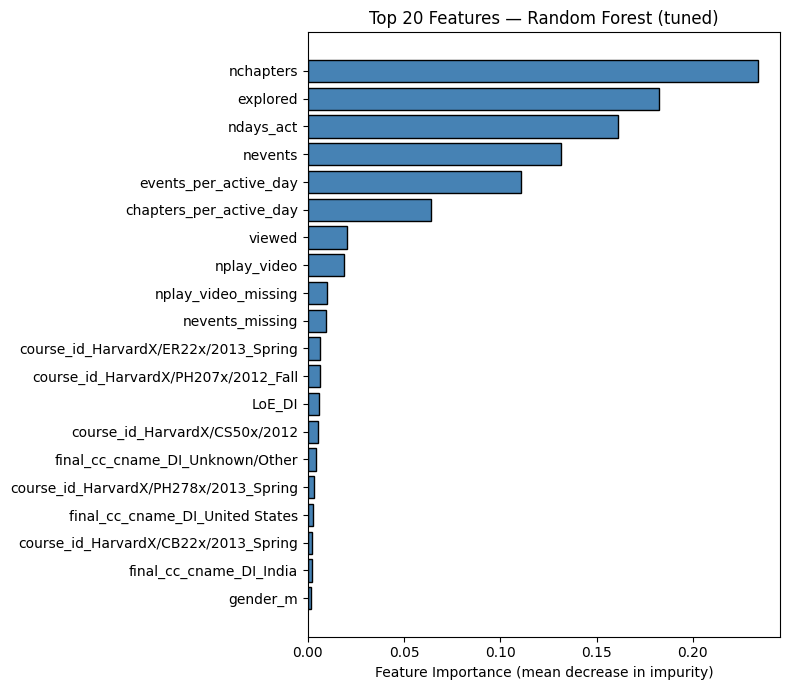

                feature  importance
              nchapters    0.233580
               explored    0.182347
              ndays_act    0.160870
                nevents    0.131265
  events_per_active_day    0.110856
chapters_per_active_day    0.063793
                 viewed    0.020203
            nplay_video    0.018645
    nplay_video_missing    0.009970
        nevents_missing    0.009247


In [12]:
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature':    features,
    'importance': importances,
}).sort_values('importance', ascending=False)

top_n   = 20
plot_df = feat_imp_df.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_df['feature'], plot_df['importance'],
        color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_title(f'Top {top_n} Features — Random Forest (tuned)')
plt.tight_layout()
plt.show()

print(feat_imp_df.head(10).to_string(index=False))

---
## 7. Generate Predictions and Save Submission

Finally, we retrain the final model on the full training dataset (rather than just the 80% training split) before predicting on the test set. During model development, we held out 20% as a validation set to get an honest estimate of generalization performance and tune hyperparameters. Once we've settled on the best model configuration, there's no reason to leave that data on the table. So now we retrain on all available labeled data to give the model more examples to learn from. This hopefully helps us our prediction quality on unseen test data.

In [13]:
final_model = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1,
    **search.best_params_
)
final_model.fit(train_proc[features], train_proc[target])
predictions = final_model.predict(X_test)

submission = pd.DataFrame({'userid_DI': test_ids, 'certified': predictions})
assert len(submission) == 2920, f'Expected 2920 rows, got {len(submission)}'
submission.to_csv('submission.csv', index=False)

print('submission.csv saved.')
print(f'  Rows          : {len(submission)}')
print(f'  Certified = 1 : {predictions.sum()} ({predictions.mean():.2%})')
print(f'  Certified = 0 : {(predictions == 0).sum()} ({(predictions == 0).mean():.2%})')
print()
print(submission.head(10))

submission.csv saved.
  Rows          : 2920
  Certified = 1 : 1276 (43.70%)
  Certified = 0 : 1644 (56.30%)

        userid_DI  certified
0  MHxPC130476531          1
1  MHxPC130559898          0
2  MHxPC130552712          1
3  MHxPC130394971          1
4  MHxPC130191077          1
5  MHxPC130286802          0
6  MHxPC130043352          0
7  MHxPC130419313          0
8  MHxPC130388505          1
9  MHxPC130009360          1


---
## 8. Ethical Implications

When using a model like this, if used in paid-certificate marketing, raises some concerns. Features like nforum_posts, nplay_video, and ndays_act are strong predictors but also indicators of free time and reliable internet access. If a student for example works full-time or has unstable internet will be structurally disadvantaged and will likely be predicted as likely to get the certificate. LoE_DI (education level) and final_cc_cname_DI (country) encode socioeconomic and geographic disparities, so a model trained on historical data will perpetuate them. The explored flag is also a proxy for the outcome itself and could create a feedback loop where students the model ranks low receive less marketing attention, engage less, and confirm the model's prediction. This isn't necessessarily because they can't certify, but it's because they weren't targeted. Moreover, students in underrepresented countries or with missing demographic data (mapped to 'Unknown') are likely to be systematically deprioritized.